# 05 - Full System Backtest & Evaluation

This notebook provides comprehensive backtesting and evaluation of the complete 3-level hierarchical RL portfolio system.

## Evaluation Goals

1. **Performance Analysis**: Evaluate Meta Agent (full system) on test set
2. **Benchmark Comparison**: Compare against QQQ (Nasdaq-100 buy-and-hold)
3. **Transaction Cost Analysis**: Assess impact of portfolio turnover
4. **Risk Metrics**: Comprehensive risk-adjusted performance
5. **Portfolio Composition**: Analyze allocation patterns over time
6. **Final Report**: Production-ready performance summary

---

## Step 1: Setup & Imports

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Add helpers to path
sys.path.append('..')

from helpers import (
    create_meta_agent_env,
    create_super_agent_env,
    evaluate_meta_agent,
    calculate_all_metrics,
    plot_equity_curve,
    plot_drawdown,
    load_features_and_returns,
    evaluate_agent,
    evaluate_super_agent
)


from helpers.environments import create_env
from stable_baselines3 import PPO

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Imports successful")
print(f"Working directory: {os.getcwd()}")
print(f"Evaluation date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Imports successful
Working directory: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/harlf_weekly/notebooks
Evaluation date: 2025-11-07 12:44:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Step 2: Load All Trained Models & Results

In [2]:
# Define paths and load results/models following the data structure in the image

MODELS_DIR = Path('../models')
DATA_DIR = Path('../data_hierarchical')

# Load metadata
with open(DATA_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print("Portfolio Configuration:")
print(f"  Tickers: {', '.join(metadata['tickers'])}")
print(f"  Benchmark: {metadata['benchmark']}")
print(f"  Total Weeks: {metadata['date_range']['total_weeks']}")
print(f"  Date Range: {metadata['date_range']['start']} to {metadata['date_range']['end']}")

print(f"\nTest Set:")
print(f"  Period: {metadata['splits']['test']['start']} to {metadata['splits']['test']['end']}")
print(f"  Weeks: {metadata['splits']['test']['weeks']}")

# Load all agent results
print("\nLoading trained agent results...")

with open(MODELS_DIR / 'technical_ema_sharpe_results.json', 'r') as f:
    tech_results = json.load(f)

with open(MODELS_DIR / 'sentiment_ema_sharpe_results.json', 'r') as f:
    sent_results = json.load(f)

with open(MODELS_DIR / 'super_agent_results.json', 'r') as f:
    super_results = json.load(f)

with open(MODELS_DIR / 'meta_agent_results.json', 'r') as f:
    meta_results = json.load(f)

print("✓ All agent results loaded")

# Load Meta Agent model
meta_agent_path = MODELS_DIR / 'meta_agent_production.zip'

print(f"\nLoading Meta Agent model from: {meta_agent_path}")
meta_model = PPO.load(meta_agent_path)
print("✓ Meta Agent model loaded")

Portfolio Configuration:
  Tickers: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  Benchmark: QQQ
  Total Weeks: 306
  Date Range: 2020-01-03 to 2025-11-07

Test Set:
  Period: 2025-04-11 to 2025-11-07
  Weeks: 31

Loading trained agent results...
✓ All agent results loaded

Loading Meta Agent model from: ../models/meta_agent_production.zip
✓ Meta Agent model loaded


## Step 3: Load Benchmark Data (QQQ)

We'll compare our hierarchical RL system against a simple buy-and-hold strategy in QQQ.

In [3]:
import yfinance as yf

print("Downloading QQQ benchmark data...")

# Download QQQ data for the full period
start_date = metadata['date_range']['start']
end_date = metadata['date_range']['end']

qqq_data = yf.download('QQQ', start=start_date, end=end_date, auto_adjust=True, progress=False)

# Handle column structure
if isinstance(qqq_data.columns, pd.MultiIndex):
    qqq_data.columns = qqq_data.columns.get_level_values(0)

qqq_data.columns = [str(col).lower().replace(' ', '_') for col in qqq_data.columns]
adj_close_col = 'adj_close' if 'adj_close' in qqq_data.columns else 'close'

# Resample to weekly (Friday close)
qqq_weekly = qqq_data[adj_close_col].resample('W-FRI').last().ffill()

# Calculate weekly returns
qqq_returns = qqq_weekly.pct_change().dropna()

# Get test period returns
test_start = metadata['splits']['test']['start']
test_end = metadata['splits']['test']['end']
qqq_test_returns = qqq_returns.loc[test_start:test_end]

print(f"✓ QQQ benchmark data loaded")
print(f"  Test period weeks: {len(qqq_test_returns)}")
print(f"  Date range: {qqq_test_returns.index[0].strftime('%Y-%m-%d')} to {qqq_test_returns.index[-1].strftime('%Y-%m-%d')}")

✓ QQQ benchmark data loaded
  Test period weeks: 31
  Date range: 2025-04-11 to 2025-11-07


## Step 4: Calculate Benchmark Metrics

In [4]:
# Calculate QQQ benchmark metrics
qqq_metrics = calculate_all_metrics(qqq_test_returns.values)

print("QQQ Benchmark Performance (Test Set):")
print("="*60)
print(f"  Total Return: {qqq_metrics['total_return']:.2%}")
print(f"  Annual Return: {qqq_metrics['annual_return']:.2%}")
print(f"  Annual Volatility: {qqq_metrics['annual_volatility']:.2%}")
print(f"  Sharpe Ratio: {qqq_metrics['sharpe']:.3f}")
print(f"  Sortino Ratio: {qqq_metrics['sortino']:.3f}")
print(f"  Max Drawdown: {qqq_metrics['max_drawdown']:.2%}")
print(f"  Calmar Ratio: {qqq_metrics['calmar']:.3f}")
print(f"  Win Rate: {qqq_metrics['win_rate']:.2%}")

QQQ Benchmark Performance (Test Set):
  Total Return: 45.05%
  Annual Return: 64.46%
  Annual Volatility: 18.68%
  Sharpe Ratio: 3.237
  Sortino Ratio: 8.349
  Max Drawdown: -2.77%
  Calmar Ratio: 23.305
  Win Rate: 61.29%


In [5]:
# =============================================================================
# EVALUATE ALL AGENTS ON TEST SET (FIRST TIME!)
# =============================================================================
print("\n" + "="*80)
print("⚠️  EVALUATING ALL AGENTS ON TEST SET FOR THE FIRST TIME")
print("   This is our true out-of-sample performance estimate")
print("="*80 + "\n")



# =============================================================================
# 1. EVALUATE BASE AGENTS (Level 1)
# =============================================================================
print("Level 1 - Base Agents:")
print("-" * 80)

# Technical Agent
print("\n[1/4] Evaluating Technical Agent on test set...")
technical_model = PPO.load(MODELS_DIR / 'technical_ema_sharpe.zip')
tech_results_raw = evaluate_agent(
    model=technical_model,
    agent_type='technical',
    split='test',
    reward_type='ema_sharpe',
    n_episodes=1,
    verbose=1
)
# Flatten structure to match super/meta agent format
tech_test = {
    **tech_results_raw['metrics'],  # Unpack all metrics to top level
    'returns': tech_results_raw['returns']
}

# Sentiment Agent
print("\n[2/4] Evaluating Sentiment Agent on test set...")
sentiment_model = PPO.load(MODELS_DIR / 'sentiment_ema_sharpe.zip')
sent_results_raw = evaluate_agent(
    model=sentiment_model,
    agent_type='sentiment',
    split='test',
    reward_type='ema_sharpe',
    n_episodes=1,
    verbose=1
)
# Flatten structure
sent_test = {
    **sent_results_raw['metrics'],
    'returns': sent_results_raw['returns']
}

# =============================================================================
# 2. EVALUATE SUPER AGENT (Level 2)
# =============================================================================
print("\n\nLevel 2 - Super Agent:")
print("-" * 80)
print("\n[3/4] Evaluating Super Agent on test set...")

technical_model_path = MODELS_DIR / 'technical_ema_sharpe.zip'
sentiment_model_path = MODELS_DIR / 'sentiment_ema_sharpe.zip'

super_env_test = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='test',
    reward_type='ema_sharpe'
)

super_model = PPO.load(MODELS_DIR / 'super_agent_production.zip')
super_test = evaluate_super_agent(
    model=super_model,
    env=super_env_test,
    split='test',
    n_episodes=1
)

print(f"Super Agent Test Sharpe: {super_test['sharpe']:.3f}")

# =============================================================================
# 3. EVALUATE META AGENT (Level 3)
# =============================================================================
print("\n\nLevel 3 - Meta Agent:")
print("-" * 80)
print("\n[4/4] Evaluating Meta Agent on test set...")

super_agent_path = MODELS_DIR / 'super_agent_production.zip'

# Recreate super env for meta agent
super_env_test_meta = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='test',
    reward_type='ema_sharpe'
)

test_env = create_meta_agent_env(
    super_agent_path=super_agent_path,
    super_env=super_env_test_meta,
    split='test',
    reward_type='ema_sharpe'
)

test_meta = evaluate_meta_agent(meta_model, test_env, split='test')

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*80)
print("✅ ALL AGENTS EVALUATED ON TEST SET (FIRST TIME!)")
print("="*80)
print(f"\nLevel 1 - Base Agents:")
print(f"  Technical Agent - Sharpe: {tech_test['sharpe']:.3f}, Return: {tech_test['annual_return']:.2%}")
print(f"  Sentiment Agent - Sharpe: {sent_test['sharpe']:.3f}, Return: {sent_test['annual_return']:.2%}")
print(f"\nLevel 2 - Super Agent:")
print(f"  Sharpe: {super_test['sharpe']:.3f}, Return: {super_test['annual_return']:.2%}")
print(f"\nLevel 3 - Meta Agent:")
print(f"  Sharpe: {test_meta['sharpe']:.3f}, Return: {test_meta['annual_return']:.2%}")
print(f"\n⚠️  DO NOT retrain based on these results!")
print("="*80 + "\n")



⚠️  EVALUATING ALL AGENTS ON TEST SET FOR THE FIRST TIME
   This is our true out-of-sample performance estimate

Level 1 - Base Agents:
--------------------------------------------------------------------------------

[1/4] Evaluating Technical Agent on test set...

EVALUATING AGENT ON TEST SET

TEST Set Performance
Total Return:          94.74%
Annual Return:        117.40%
Annual Volatility:     30.15%
Sharpe Ratio:           3.76
Sortino Ratio:          8.09
Max Drawdown:          -5.55%
Calmar Ratio:          21.16
Win Rate:              74.19%
N Periods:                31


[2/4] Evaluating Sentiment Agent on test set...

EVALUATING AGENT ON TEST SET

TEST Set Performance
Total Return:         110.66%
Annual Return:        131.37%
Annual Volatility:     32.46%
Sharpe Ratio:           3.92
Sortino Ratio:         14.87
Max Drawdown:          -4.31%
Calmar Ratio:          30.48
Win Rate:              74.19%
N Periods:                31



Level 2 - Super Agent:
---------------------

## Step 5: Hierarchical System vs Benchmark Comparison

Hierarchical System vs Benchmark Comparison


        Agent   Sharpe  Annual Return  Volatility    Max DD
    Technical 3.761342       1.173973    0.301481 -0.055471
    Sentiment 3.923402       1.313717    0.324646 -0.043107
  Super Agent 4.053407       1.226240    0.292652 -0.048044
   Meta Agent 3.839684       1.535494    0.389484 -0.056357
QQQ Benchmark 3.236854       0.644616    0.186791 -0.027660


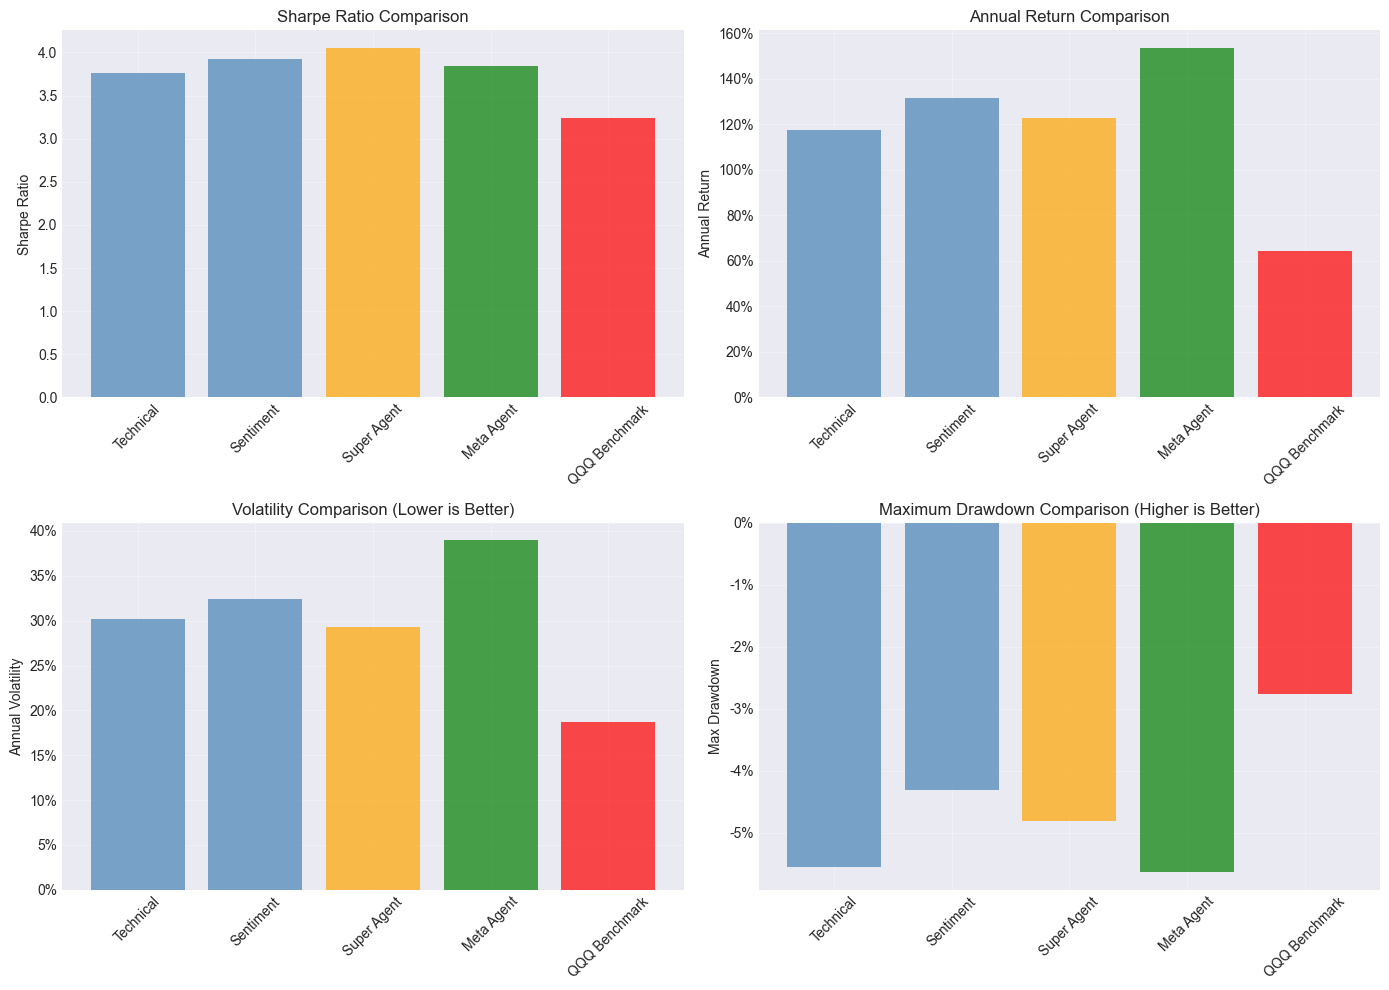

In [6]:
# Compare all hierarchical agents and benchmark
print("Hierarchical System vs Benchmark Comparison")
print("="*60)

# Create comparison table
comparison_data = {
    'Agent': ['Technical', 'Sentiment', 'Super Agent', 'Meta Agent', 'QQQ Benchmark'],
    'Sharpe': [tech_test['sharpe'], sent_test['sharpe'], super_test['sharpe'], 
               test_meta['sharpe'], qqq_metrics['sharpe']],
    'Annual Return': [tech_test['annual_return'], sent_test['annual_return'], 
                      super_test['annual_return'], test_meta['annual_return'], 
                      qqq_metrics['annual_return']],
    'Volatility': [tech_test['annual_volatility'], sent_test['annual_volatility'], 
                   super_test['annual_volatility'], test_meta['annual_volatility'], 
                   qqq_metrics['annual_volatility']],
    'Max DD': [tech_test['max_drawdown'], sent_test['max_drawdown'], 
               super_test['max_drawdown'], test_meta['max_drawdown'], 
               qqq_metrics['max_drawdown']]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sharpe Ratio comparison
axes[0, 0].bar(comparison_df['Agent'], comparison_df['Sharpe'], 
               color=['steelblue', 'steelblue', 'orange', 'green', 'red'], alpha=0.7)
axes[0, 0].set_ylabel('Sharpe Ratio')
axes[0, 0].set_title('Sharpe Ratio Comparison')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Annual Return comparison
axes[0, 1].bar(comparison_df['Agent'], comparison_df['Annual Return'], 
               color=['steelblue', 'steelblue', 'orange', 'green', 'red'], alpha=0.7)
axes[0, 1].set_ylabel('Annual Return')
axes[0, 1].set_title('Annual Return Comparison')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Volatility comparison
axes[1, 0].bar(comparison_df['Agent'], comparison_df['Volatility'], 
               color=['steelblue', 'steelblue', 'orange', 'green', 'red'], alpha=0.7)
axes[1, 0].set_ylabel('Annual Volatility')
axes[1, 0].set_title('Volatility Comparison (Lower is Better)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Max Drawdown comparison
axes[1, 1].bar(comparison_df['Agent'], comparison_df['Max DD'], 
               color=['steelblue', 'steelblue', 'orange', 'green', 'red'], alpha=0.7)
axes[1, 1].set_ylabel('Max Drawdown')
axes[1, 1].set_title('Maximum Drawdown Comparison (Higher is Better)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

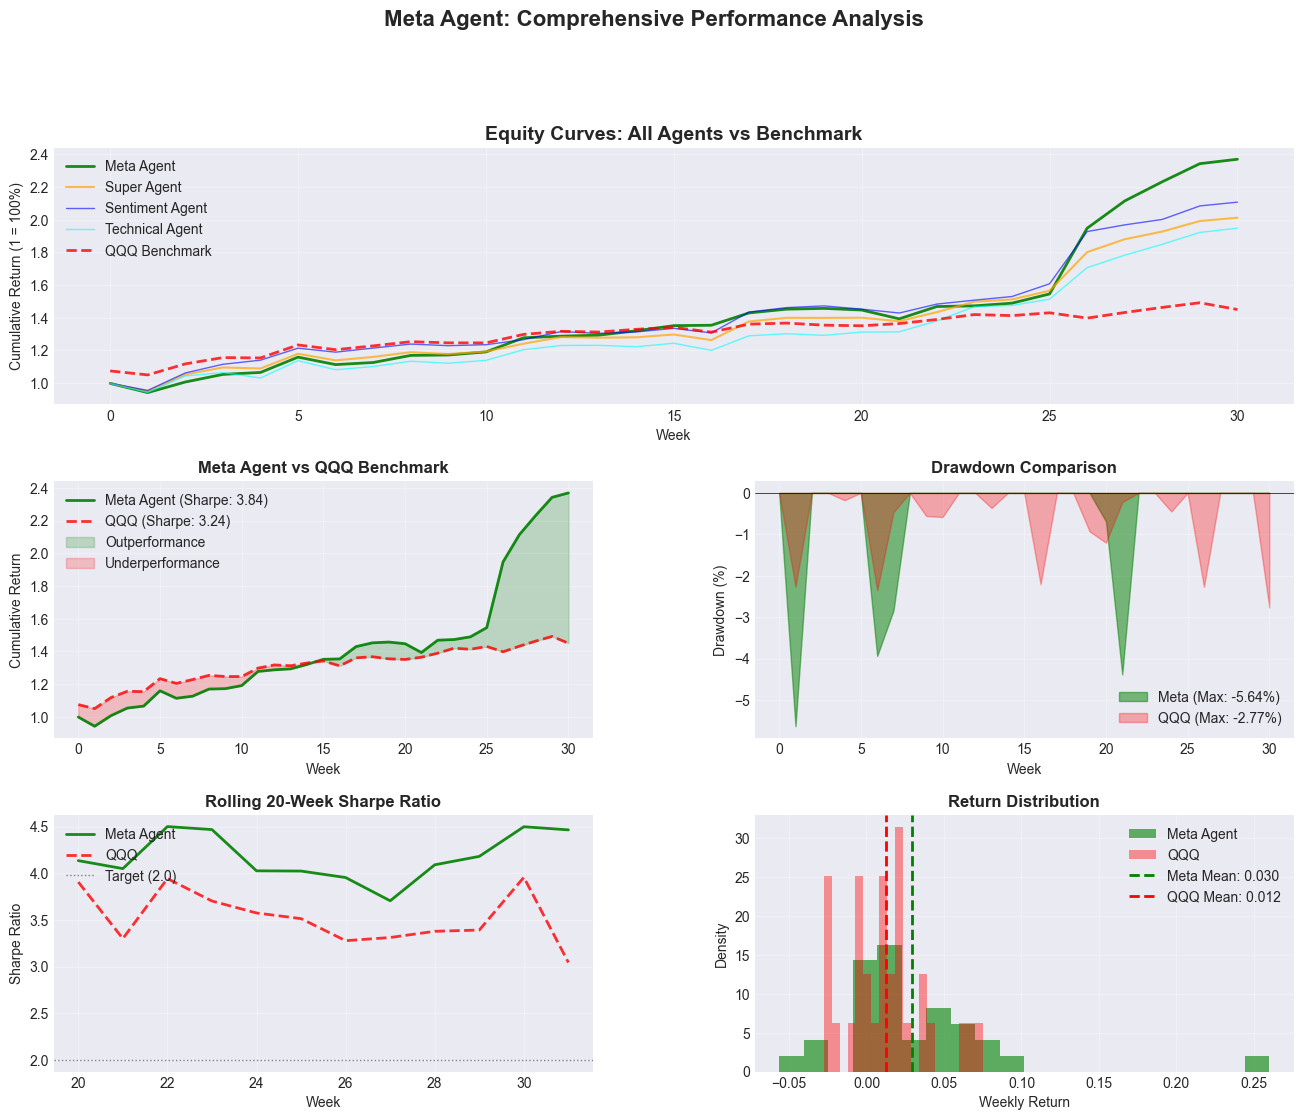


✓ All visualizations generated successfully


In [7]:
# Comprehensive visualizations of Meta Agent performance

# Calculate cumulative returns for all agents
meta_cumulative = (1 + np.array(test_meta['returns'])).cumprod()
qqq_cumulative = (1 + qqq_test_returns.values).cumprod()
tech_cumulative = (1 + np.array(tech_test['returns'])).cumprod()
sent_cumulative = (1 + np.array(sent_test['returns'])).cumprod()
super_cumulative = (1 + np.array(super_test['returns'])).cumprod()

# Calculate drawdowns
def calculate_drawdown(cumulative_returns):
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown

meta_dd = calculate_drawdown(meta_cumulative)
qqq_dd = calculate_drawdown(qqq_cumulative)

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Equity curves - All agents
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(meta_cumulative, label='Meta Agent', linewidth=2, color='green', alpha=0.9)
ax1.plot(super_cumulative, label='Super Agent', linewidth=1.5, color='orange', alpha=0.7)
ax1.plot(sent_cumulative, label='Sentiment Agent', linewidth=1, color='blue', alpha=0.6)
ax1.plot(tech_cumulative, label='Technical Agent', linewidth=1, color='cyan', alpha=0.6)
ax1.plot(qqq_cumulative, label='QQQ Benchmark', linewidth=2, color='red', alpha=0.8, linestyle='--')
ax1.set_xlabel('Week')
ax1.set_ylabel('Cumulative Return (1 = 100%)')
ax1.set_title('Equity Curves: All Agents vs Benchmark', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Meta Agent vs QQQ only
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(meta_cumulative, label=f'Meta Agent (Sharpe: {test_meta["sharpe"]:.2f})', 
         linewidth=2, color='green', alpha=0.9)
ax2.plot(qqq_cumulative, label=f'QQQ (Sharpe: {qqq_metrics["sharpe"]:.2f})', 
         linewidth=2, color='red', alpha=0.8, linestyle='--')
ax2.fill_between(range(len(meta_cumulative)), meta_cumulative, qqq_cumulative, 
                  where=(meta_cumulative >= qqq_cumulative), color='green', alpha=0.2, 
                  label='Outperformance')
ax2.fill_between(range(len(meta_cumulative)), meta_cumulative, qqq_cumulative, 
                  where=(meta_cumulative < qqq_cumulative), color='red', alpha=0.2, 
                  label='Underperformance')
ax2.set_xlabel('Week')
ax2.set_ylabel('Cumulative Return')
ax2.set_title('Meta Agent vs QQQ Benchmark', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# 3. Drawdown comparison
ax3 = fig.add_subplot(gs[1, 1])
ax3.fill_between(range(len(meta_dd)), meta_dd * 100, 0, color='green', alpha=0.5, 
                  label=f'Meta (Max: {test_meta["max_drawdown"]:.2%})')
ax3.fill_between(range(len(qqq_dd)), qqq_dd * 100, 0, color='red', alpha=0.3, 
                  label=f'QQQ (Max: {qqq_metrics["max_drawdown"]:.2%})')
ax3.set_xlabel('Week')
ax3.set_ylabel('Drawdown (%)')
ax3.set_title('Drawdown Comparison', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 4. Rolling Sharpe Ratio (20-week window)
ax4 = fig.add_subplot(gs[2, 0])
window = 20
if len(test_meta['returns']) >= window:
    meta_returns_array = np.array(test_meta['returns'])
    qqq_returns_array = qqq_test_returns.values
    
    meta_rolling_sharpe = []
    qqq_rolling_sharpe = []
    
    for i in range(window, len(meta_returns_array) + 1):
        meta_window = meta_returns_array[i-window:i]
        qqq_window = qqq_returns_array[i-window:i]
        
        meta_rolling_sharpe.append(np.mean(meta_window) / np.std(meta_window) * np.sqrt(52) if np.std(meta_window) > 0 else 0)
        qqq_rolling_sharpe.append(np.mean(qqq_window) / np.std(qqq_window) * np.sqrt(52) if np.std(qqq_window) > 0 else 0)
    
    ax4.plot(range(window, len(meta_returns_array) + 1), meta_rolling_sharpe, 
             label='Meta Agent', linewidth=2, color='green', alpha=0.9)
    ax4.plot(range(window, len(qqq_returns_array) + 1), qqq_rolling_sharpe, 
             label='QQQ', linewidth=2, color='red', alpha=0.8, linestyle='--')
    ax4.axhline(y=2.0, color='gray', linestyle=':', linewidth=1, label='Target (2.0)')
    ax4.set_xlabel('Week')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.set_title(f'Rolling {window}-Week Sharpe Ratio', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper left')
    ax4.grid(True, alpha=0.3)

# 5. Return distribution
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(test_meta['returns'], bins=20, alpha=0.6, color='green', label='Meta Agent', density=True)
ax5.hist(qqq_test_returns.values, bins=20, alpha=0.4, color='red', label='QQQ', density=True)
ax5.axvline(x=np.mean(test_meta['returns']), color='green', linestyle='--', linewidth=2, 
            label=f'Meta Mean: {np.mean(test_meta["returns"]):.3f}')
ax5.axvline(x=np.mean(qqq_test_returns.values), color='red', linestyle='--', linewidth=2, 
            label=f'QQQ Mean: {np.mean(qqq_test_returns.values):.3f}')
ax5.set_xlabel('Weekly Return')
ax5.set_ylabel('Density')
ax5.set_title('Return Distribution', fontsize=12, fontweight='bold')
ax5.legend(loc='upper right')
ax5.grid(True, alpha=0.3)

plt.suptitle('Meta Agent: Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n✓ All visualizations generated successfully")

## Step 6: Comprehensive Visualization

## Step 7: Transaction Cost Analysis

Analyze portfolio turnover and its impact on net returns.

Analyzing transaction costs and turnover...

Transaction Cost Analysis:

Portfolio Turnover:
  Average Weekly Turnover: 93.71%
  Total Turnover (Test Period): 2811.18%
  Annualized Turnover: 4872.71%

Transaction Costs (0.1% per trade):
  Total TC (Test Period): 0.0281 (2.81%)
  Average TC per Week: 0.000937
  Max TC in Single Week: 0.001934

Performance Impact:
  Gross Sharpe: 3.840
  Net Sharpe (after TC): 3.715
  Sharpe Degradation: 0.125

  Gross Annual Return: 153.55%
  Net Annual Return (after TC): 148.83%
  Return Degradation: 4.72%


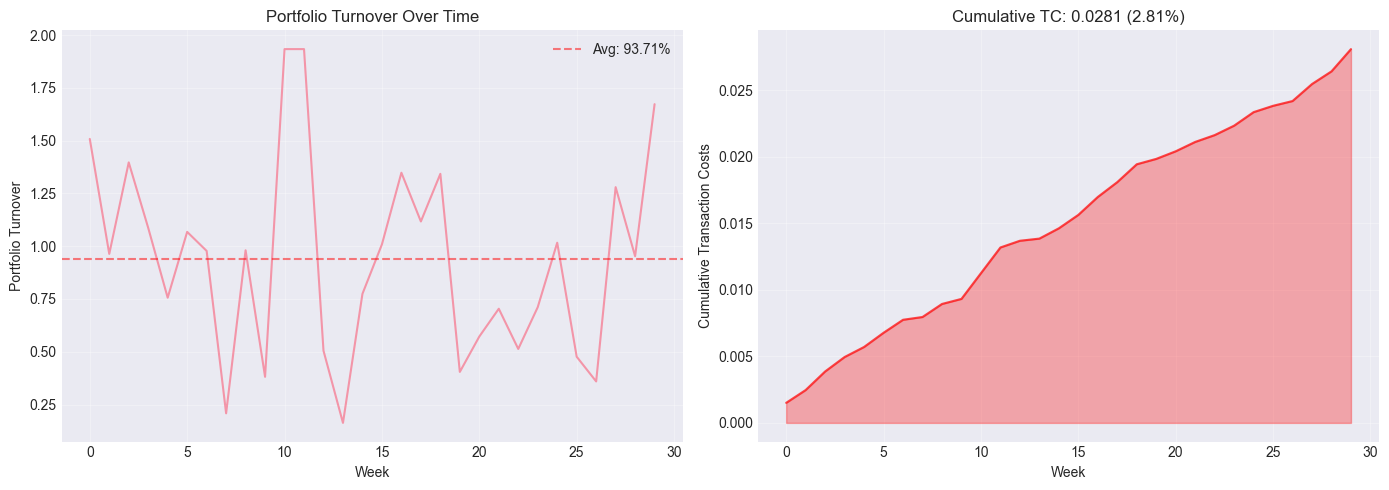

In [8]:
# Recreate test environment to get portfolio weights
print("Analyzing transaction costs and turnover...\n")

technical_model_path = MODELS_DIR / 'technical_ema_sharpe.zip'
sentiment_model_path = MODELS_DIR / 'sentiment_ema_sharpe.zip'
super_agent_path = MODELS_DIR / 'super_agent_production.zip'

# Create test environment
super_env_test = create_super_agent_env(
    technical_model_path=technical_model_path,
    sentiment_model_path=sentiment_model_path,
    split='test',
    reward_type='ema_sharpe'
)

test_env = create_meta_agent_env(
    super_agent_path=super_agent_path,
    super_env=super_env_test,
    split='test',
    reward_type='ema_sharpe'
)

# Run episode to collect portfolio weights
obs, _ = test_env.reset()
done = False
portfolio_weights = []
episode_returns = []

while not done:
    action, _ = meta_model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = test_env.step(action)

    # Get actual portfolio positions from info (these are the normalized weights)
    portfolio_weights.append(info['positions'].copy())
    done = done or truncated

portfolio_weights = np.array(portfolio_weights)

# Calculate turnover
turnover = np.abs(portfolio_weights[1:] - portfolio_weights[:-1]).sum(axis=1)
avg_turnover = turnover.mean()
total_turnover = turnover.sum()

# Calculate transaction costs (0.1% = 0.001)
transaction_cost_rate = 0.001
transaction_costs = turnover * transaction_cost_rate
total_tc = transaction_costs.sum()

# Calculate net returns after transaction costs
gross_returns = np.array(test_meta['returns'])
tc_per_period = np.concatenate([[0], transaction_costs])  # No TC on first period
net_returns = gross_returns - tc_per_period

# Recalculate metrics with transaction costs
net_metrics = calculate_all_metrics(net_returns)

print("Transaction Cost Analysis:")
print("="*60)
print(f"\nPortfolio Turnover:")
print(f"  Average Weekly Turnover: {avg_turnover:.2%}")
print(f"  Total Turnover (Test Period): {total_turnover:.2%}")
print(f"  Annualized Turnover: {avg_turnover * 52:.2%}")

print(f"\nTransaction Costs (0.1% per trade):")
print(f"  Total TC (Test Period): {total_tc:.4f} ({total_tc*100:.2f}%)")
print(f"  Average TC per Week: {transaction_costs.mean():.6f}")
print(f"  Max TC in Single Week: {transaction_costs.max():.6f}")

print(f"\nPerformance Impact:")
print(f"  Gross Sharpe: {test_meta['sharpe']:.3f}")
print(f"  Net Sharpe (after TC): {net_metrics['sharpe']:.3f}")
print(f"  Sharpe Degradation: {(test_meta['sharpe'] - net_metrics['sharpe']):.3f}")

print(f"\n  Gross Annual Return: {test_meta['annual_return']:.2%}")
print(f"  Net Annual Return (after TC): {net_metrics['annual_return']:.2%}")
print(f"  Return Degradation: {(test_meta['annual_return'] - net_metrics['annual_return']):.2%}")

# Visualize turnover
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Turnover over time
axes[0].plot(turnover, alpha=0.7)
axes[0].axhline(y=avg_turnover, color='r', linestyle='--', alpha=0.5, label=f'Avg: {avg_turnover:.2%}')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Portfolio Turnover')
axes[0].set_title('Portfolio Turnover Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative transaction costs
cumulative_tc = np.cumsum(transaction_costs)
axes[1].plot(cumulative_tc, color='red', alpha=0.7)
axes[1].fill_between(range(len(cumulative_tc)), cumulative_tc, 0, alpha=0.3, color='red')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Cumulative Transaction Costs')
axes[1].set_title(f'Cumulative TC: {total_tc:.4f} ({total_tc*100:.2f}%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 8: Portfolio Composition Analysis

Average Portfolio Allocation:
  AMD: 38.06%
  GOOG: 20.46%
  NVDA: 16.57%
  ASML: 11.15%
  MSFT: 11.11%
  AAPL: 2.46%
  MU: 0.20%


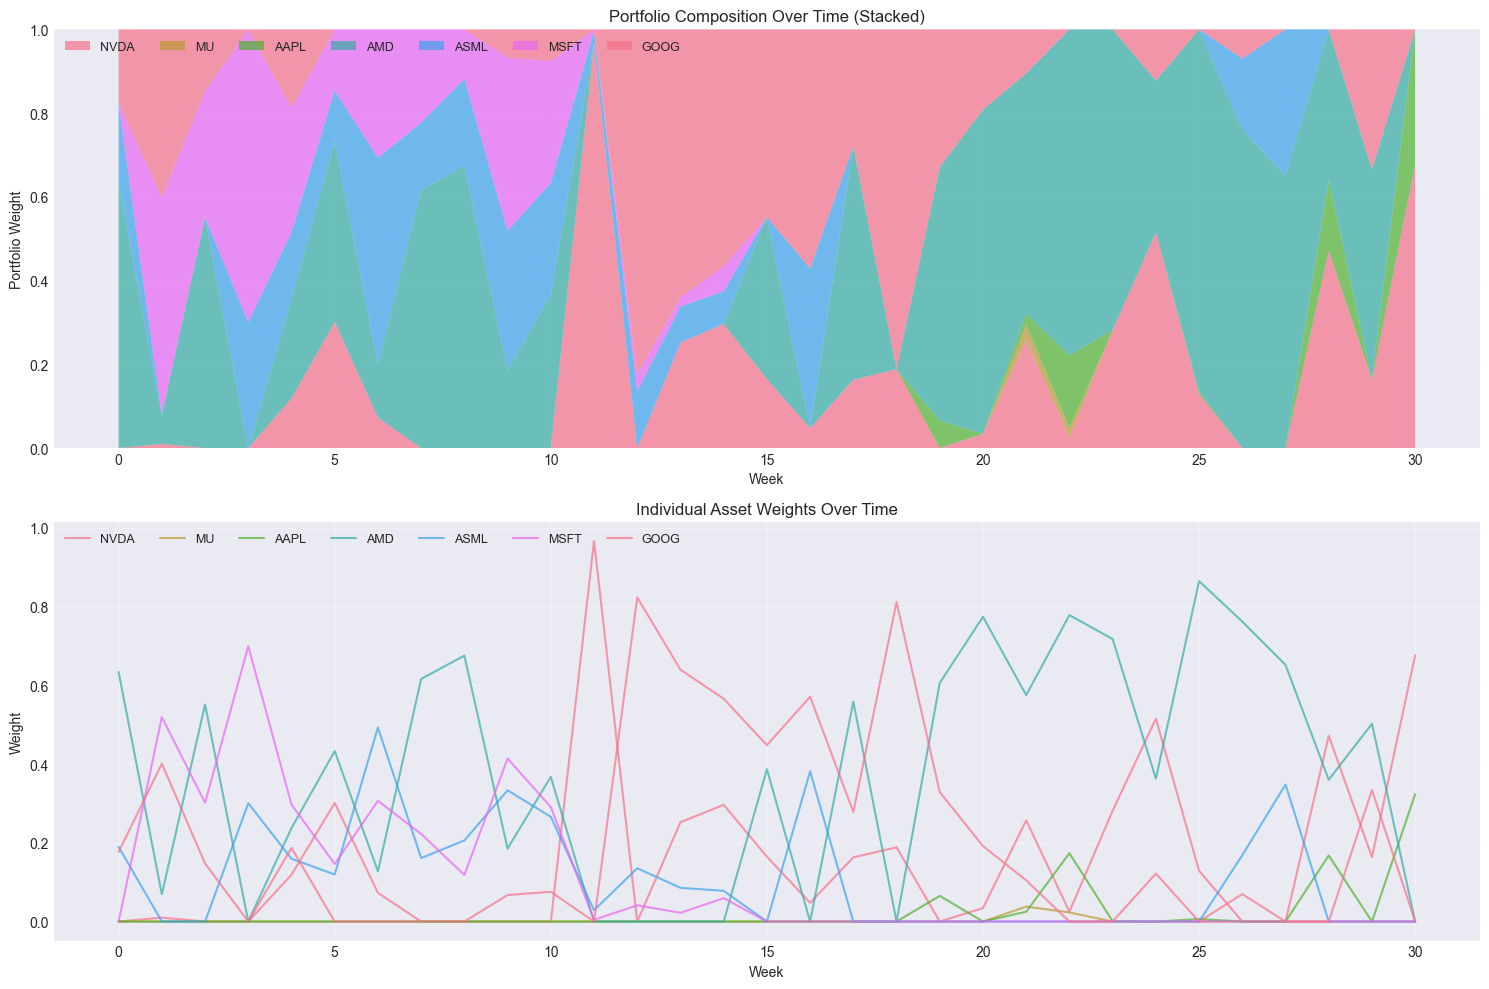


Portfolio Weight Statistics:


,NVDA,MU,AAPL,AMD,ASML,MSFT,GOOG
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,0.165687,0.001976,0.024597,0.380563,0.111451,0.111086,0.204641
std,0.228998,0.007886,0.070514,0.296251,0.141674,0.182239,0.252863
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.034653,0.000000,0.000000,0.000000
50%,0.072870,0.000000,0.000000,0.387096,0.028781,0.000000,0.104692
75%,0.254733,0.000000,0.000000,0.625011,0.179029,0.184414,0.331310
max,0.966761,0.038085,0.323605,0.864803,0.493019,0.699298,0.823375


In [9]:
# Analyze portfolio composition over time
tickers = metadata['tickers']

# Create dataframe of portfolio weights
weights_df = pd.DataFrame(portfolio_weights, columns=tickers)

# Calculate average weights
avg_weights = weights_df.mean()
print("Average Portfolio Allocation:")
print("="*60)
for ticker, weight in avg_weights.sort_values(ascending=False).items():
    print(f"  {ticker}: {weight:.2%}")

# Visualize portfolio evolution
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Stacked area chart
axes[0].stackplot(range(len(weights_df)), *[weights_df[ticker].values for ticker in tickers],
                   labels=tickers, alpha=0.7)
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Portfolio Weight')
axes[0].set_title('Portfolio Composition Over Time (Stacked)')
axes[0].legend(loc='upper left', ncol=len(tickers), fontsize=9)
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)

# Individual weight evolution
for ticker in tickers:
    axes[1].plot(weights_df[ticker], label=ticker, alpha=0.7, linewidth=1.5)

axes[1].set_xlabel('Week')
axes[1].set_ylabel('Weight')
axes[1].set_title('Individual Asset Weights Over Time')
axes[1].legend(loc='upper left', ncol=len(tickers), fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Weight statistics
print("\nPortfolio Weight Statistics:")
print("="*60)
weights_df.describe()

## Step 11: Final Portfolio Weights for Rebalancing

This section provides the **recommended portfolio allocation** based on the Meta Agent's most recent decision. Use these weights to rebalance your portfolio.

RECOMMENDED PORTFOLIO ALLOCATION
Based on Meta Agent's Most Recent Decision

CURRENT RECOMMENDED ALLOCATION

Asset      Weight       $10K Portfolio     $100K Portfolio   
--------------------------------------------------------------------------------
NVDA           67.64%   $      6,763.95   $       67,639.54
AAPL           32.36%   $      3,236.05   $       32,360.46
MU              0.00%   $          0.00   $            0.00
AMD             0.00%   $          0.00   $            0.00
ASML            0.00%   $          0.00   $            0.00
MSFT            0.00%   $          0.00   $            0.00
GOOG            0.00%   $          0.00   $            0.00
--------------------------------------------------------------------------------
TOTAL         100.00%   $     10,000.00   $      100,000.00

Note: 5 asset(s) with <1% allocation: MU, AMD, ASML, MSFT, GOOG


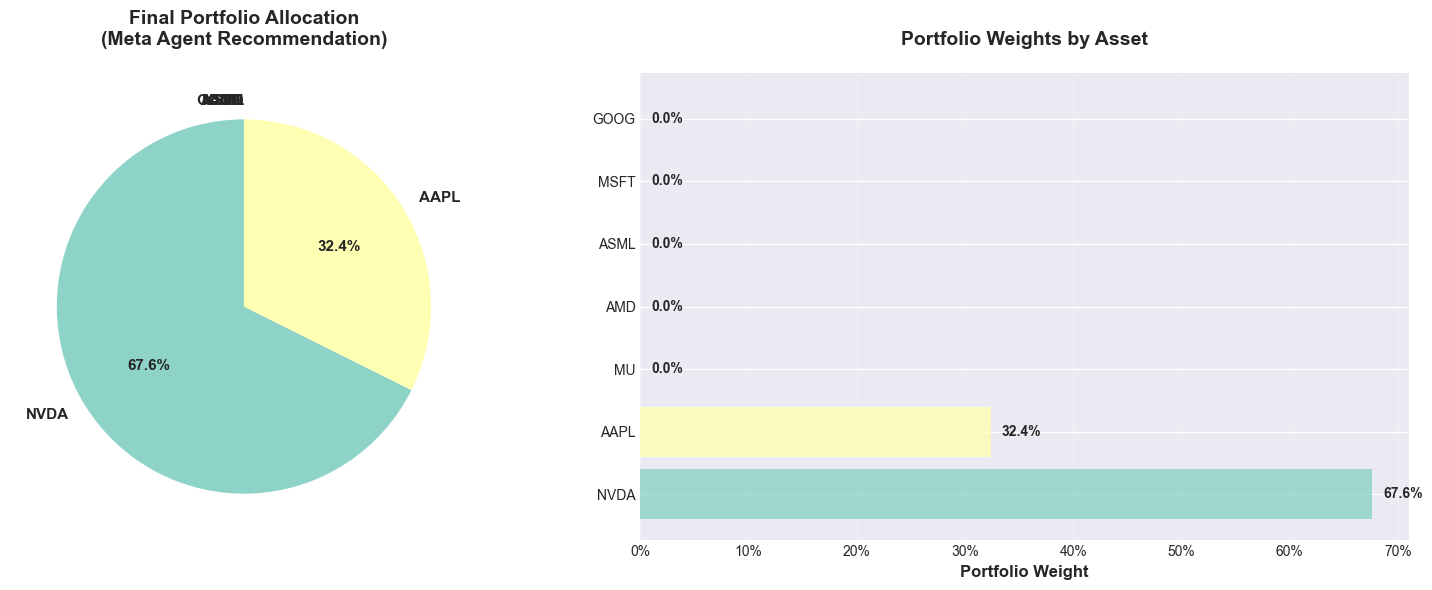


PORTFOLIO STATISTICS

Number of Holdings: 2 (with >0.1% weight)
Largest Position: 67.64% (NVDA)
Smallest Position: 0.00% (GOOG)
Top 3 Holdings: 100.00% of portfolio
Herfindahl Index: 0.562 (1.0 = fully concentrated)
Effective Number of Positions: 1.78

FINAL vs AVERAGE ALLOCATION COMPARISON

Asset      Final Weight    Avg Weight      Difference     
--------------------------------------------------------------------------------
NVDA             67.64%          16.57%         +51.07%
MU                0.00%           0.20%          -0.20%
AAPL             32.36%           2.46%         +29.90%
AMD               0.00%          38.06%         -38.06%
ASML              0.00%          11.15%         -11.15%
MSFT              0.00%          11.11%         -11.11%
GOOG              0.00%          20.46%         -20.46%

✓ Final allocation saved to: models/recommended_portfolio_allocation.json

📊 REBALANCING INSTRUCTIONS:
----------------------------------------------------------------------

In [10]:
# ============================================================================
# FINAL PORTFOLIO WEIGHTS FOR REBALANCING
# ============================================================================

print("="*80)
print("RECOMMENDED PORTFOLIO ALLOCATION")
print("Based on Meta Agent's Most Recent Decision")
print("="*80)

# Get the final (most recent) portfolio weights
final_weights = portfolio_weights[-1]
final_weights_series = pd.Series(final_weights, index=tickers).sort_values(ascending=False)

# Create allocation table
print("\n" + "="*80)
print("CURRENT RECOMMENDED ALLOCATION")
print("="*80)
print(f"\n{'Asset':<10} {'Weight':<12} {'$10K Portfolio':<18} {'$100K Portfolio':<18}")
print("-"*80)

for ticker, weight in final_weights_series.items():
    amount_10k = weight * 10000
    amount_100k = weight * 100000
    print(f"{ticker:<10} {weight:>10.2%}   ${amount_10k:>14,.2f}   ${amount_100k:>16,.2f}")

print("-"*80)
print(f"{'TOTAL':<10} {final_weights_series.sum():>10.2%}   ${10000:>14,.2f}   ${100000:>16,.2f}")
print("="*80)

# Filter out assets with <1% allocation
significant_weights = final_weights_series[final_weights_series >= 0.01]
minor_weights = final_weights_series[final_weights_series < 0.01]

if len(minor_weights) > 0:
    print(f"\nNote: {len(minor_weights)} asset(s) with <1% allocation: {', '.join(minor_weights.index.tolist())}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart with all allocations
colors = plt.cm.Set3(range(len(tickers)))
wedges, texts, autotexts = axes[0].pie(
    final_weights_series.values, 
    labels=final_weights_series.index,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11, 'weight': 'bold'}
)
axes[0].set_title('Final Portfolio Allocation\n(Meta Agent Recommendation)', 
                   fontsize=14, fontweight='bold', pad=20)

# Bar chart sorted by weight
axes[1].barh(range(len(final_weights_series)), final_weights_series.values, 
             color=colors, alpha=0.8)
axes[1].set_yticks(range(len(final_weights_series)))
axes[1].set_yticklabels(final_weights_series.index)
axes[1].set_xlabel('Portfolio Weight', fontsize=12, fontweight='bold')
axes[1].set_title('Portfolio Weights by Asset', fontsize=14, fontweight='bold', pad=20)
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Add value labels on bars
for i, (ticker, weight) in enumerate(final_weights_series.items()):
    axes[1].text(weight + 0.01, i, f'{weight:.1%}', 
                 va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Portfolio statistics
print("\n" + "="*80)
print("PORTFOLIO STATISTICS")
print("="*80)
print(f"\nNumber of Holdings: {(final_weights_series > 0.001).sum()} (with >0.1% weight)")
print(f"Largest Position: {final_weights_series.iloc[0]:.2%} ({final_weights_series.index[0]})")
print(f"Smallest Position: {final_weights_series.iloc[-1]:.2%} ({final_weights_series.index[-1]})")
print(f"Top 3 Holdings: {final_weights_series[:3].sum():.2%} of portfolio")
print(f"Herfindahl Index: {(final_weights_series ** 2).sum():.3f} (1.0 = fully concentrated)")
print(f"Effective Number of Positions: {1 / (final_weights_series ** 2).sum():.2f}")

# Comparison with average weights
print("\n" + "="*80)
print("FINAL vs AVERAGE ALLOCATION COMPARISON")
print("="*80)
print(f"\n{'Asset':<10} {'Final Weight':<15} {'Avg Weight':<15} {'Difference':<15}")
print("-"*80)

for ticker in tickers:
    final_wt = final_weights_series[ticker]
    avg_wt = avg_weights[ticker]
    diff = final_wt - avg_wt
    print(f"{ticker:<10} {final_wt:>12.2%}    {avg_wt:>12.2%}    {diff:>+12.2%}")

# Save final weights to JSON
final_allocation = {
    'date': datetime.now().isoformat(),
    'period': f"{metadata['splits']['test']['end']}",
    'allocation': {ticker: float(weight) for ticker, weight in final_weights_series.items()},
    'statistics': {
        'num_holdings': int((final_weights_series > 0.001).sum()),
        'largest_position': float(final_weights_series.iloc[0]),
        'largest_position_ticker': str(final_weights_series.index[0]),
        'herfindahl_index': float((final_weights_series ** 2).sum()),
        'effective_num_positions': float(1 / (final_weights_series ** 2).sum()),
        'top_3_concentration': float(final_weights_series[:3].sum())
    },
    'performance_metrics': {
        'sharpe_ratio': float(net_metrics['sharpe']),
        'annual_return': float(net_metrics['annual_return']),
        'annual_volatility': float(net_metrics['annual_volatility']),
        'max_drawdown': float(net_metrics['max_drawdown'])
    }
}

with open('../models/recommended_portfolio_allocation.json', 'w') as f:
    json.dump(final_allocation, f, indent=2)

print("\n" + "="*80)
print("✓ Final allocation saved to: models/recommended_portfolio_allocation.json")
print("="*80)

print("\n📊 REBALANCING INSTRUCTIONS:")
print("-"*80)
print("1. Use the weights above to calculate dollar amounts for your portfolio size")
print("2. Account for 0.1% transaction costs when rebalancing")
print("3. Consider rebalancing weekly (Friday close) to follow the model's strategy")
print("4. Monitor performance and re-evaluate allocation periodically")
print("5. This allocation is based on historical backtesting - past performance")
print("   does not guarantee future results")
print("="*80)


COMPARING FINAL ALLOCATIONS ACROSS ALL MODELS

  [1/4] Technical Agent...
  [2/4] Sentiment Agent...
  [3/4] Super Agent...
  [4/4] Meta Agent... (already collected)
✓ All final allocations collected

FINAL ALLOCATION COMPARISON TABLE
      Technical  Sentiment  Super Agent  Meta Agent
NVDA   0.314884   0.453465     0.423677    0.676395
MU     0.000000   0.000000     0.000000    0.000000
AAPL   0.164555   0.098428     0.188569    0.323605
AMD    0.000000   0.000000     0.000000    0.000000
ASML   0.006960   0.448107     0.249117    0.000000
MSFT   0.355040   0.000000     0.138637    0.000000
GOOG   0.158561   0.000000     0.000000    0.000000


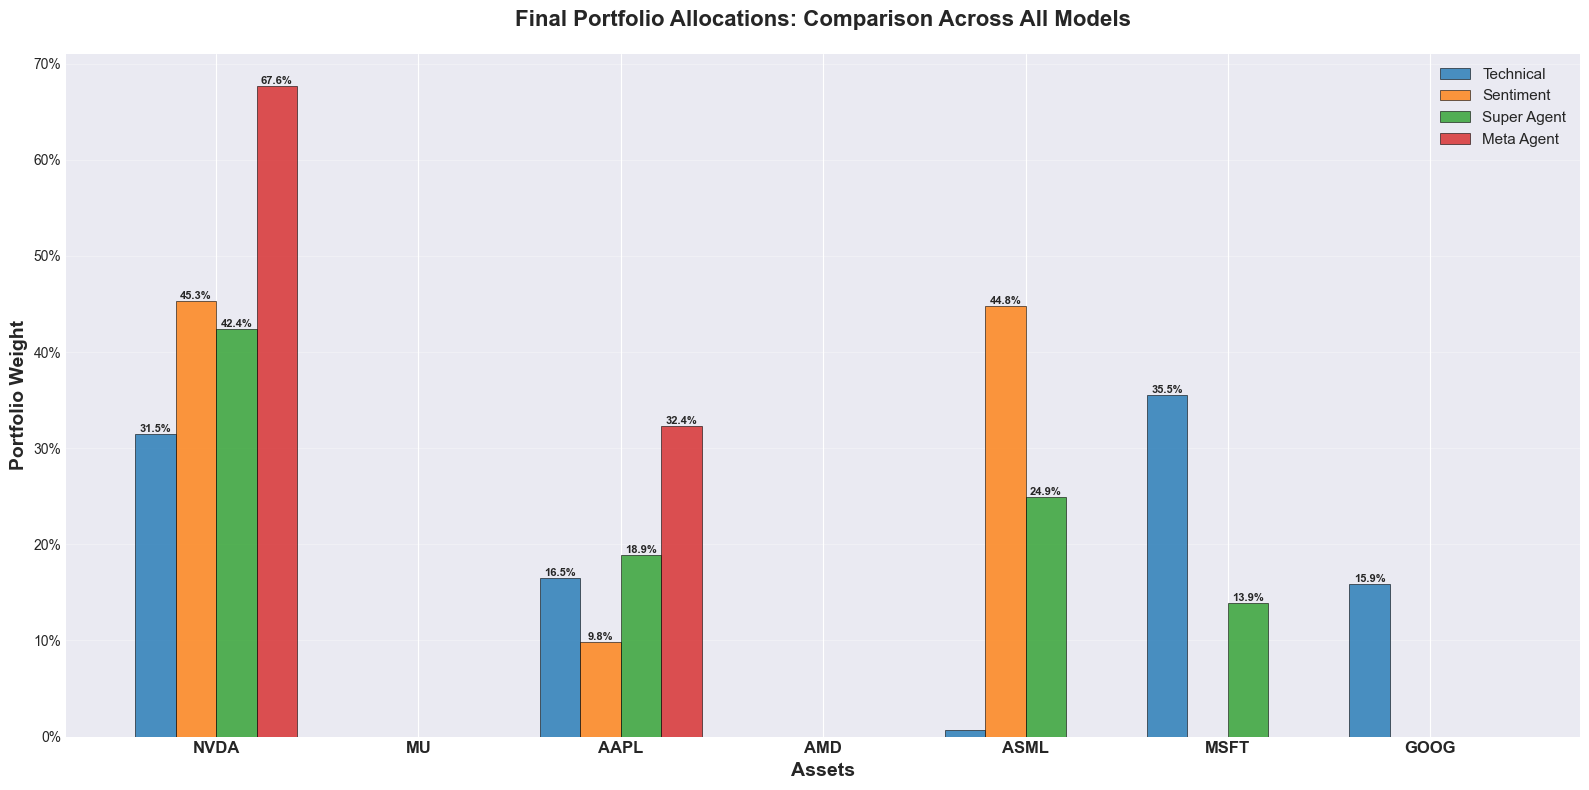


ALLOCATION STATISTICS BY MODEL

Technical:
  Max position: 35.50% (MSFT)
  Min position: 0.00% (MU)
  Herfindahl: 0.277
  Effective N: 3.60
  Non-zero positions: 4

Sentiment:
  Max position: 45.35% (NVDA)
  Min position: 0.00% (MU)
  Herfindahl: 0.416
  Effective N: 2.40
  Non-zero positions: 3

Super Agent:
  Max position: 42.37% (NVDA)
  Min position: 0.00% (MU)
  Herfindahl: 0.296
  Effective N: 3.37
  Non-zero positions: 4

Meta Agent:
  Max position: 67.64% (NVDA)
  Min position: 0.00% (MU)
  Herfindahl: 0.562
  Effective N: 1.78
  Non-zero positions: 2

DIVERSIFICATION RANKING (Lower Herfindahl = More Diversified)
  1. Technical       Herfindahl: 0.277
  2. Super Agent     Herfindahl: 0.296
  3. Sentiment       Herfindahl: 0.416
  4. Meta Agent      Herfindahl: 0.562

✓ Comparison saved to: models/allocation_comparison_all_models.json


In [11]:
# ============================================================================
# COMPARISON: FINAL ALLOCATIONS FROM ALL 4 MODELS
# ============================================================================

print("\n" + "="*80)
print("COMPARING FINAL ALLOCATIONS ACROSS ALL MODELS")
print("="*80)

# We already have Meta Agent's final weights
meta_final_weights = portfolio_weights[-1]

# Get Technical Agent's final allocation
print("\nCollecting final allocations from each agent...")
print("  [1/4] Technical Agent...")


tech_env = create_env(agent_type='technical', split='test', reward_type='ema_sharpe')
tech_obs, _ = tech_env.reset()
tech_done = False
tech_weights_list = []

while not tech_done:
    tech_action, _ = technical_model.predict(tech_obs, deterministic=True)
    tech_obs, _, tech_done, tech_truncated, tech_info = tech_env.step(tech_action)
    tech_weights_list.append(tech_info['positions'].copy())
    tech_done = tech_done or tech_truncated

tech_final_weights = tech_weights_list[-1]

# Get Sentiment Agent's final allocation
print("  [2/4] Sentiment Agent...")
sent_env = create_env(agent_type='sentiment', split='test', reward_type='ema_sharpe')
sent_obs, _ = sent_env.reset()
sent_done = False
sent_weights_list = []

while not sent_done:
    sent_action, _ = sentiment_model.predict(sent_obs, deterministic=True)
    sent_obs, _, sent_done, sent_truncated, sent_info = sent_env.step(sent_action)
    sent_weights_list.append(sent_info['positions'].copy())
    sent_done = sent_done or sent_truncated

sent_final_weights = sent_weights_list[-1]

# Get Super Agent's final allocation
print("  [3/4] Super Agent...")
super_env_for_weights = create_super_agent_env(
    technical_model_path=MODELS_DIR / 'technical_ema_sharpe.zip',
    sentiment_model_path=MODELS_DIR / 'sentiment_ema_sharpe.zip',
    split='test',
    reward_type='ema_sharpe'
)

super_obs, _ = super_env_for_weights.reset()
super_done = False
super_weights_list = []

while not super_done:
    super_action, _ = super_model.predict(super_obs, deterministic=True)
    super_obs, _, super_done, super_truncated, super_info = super_env_for_weights.step(super_action)
    super_weights_list.append(super_info['positions'].copy())
    super_done = super_done or super_truncated

super_final_weights = super_weights_list[-1]

print("  [4/4] Meta Agent... (already collected)")
print("✓ All final allocations collected")

# Create comparison dataframe
allocations_comparison = pd.DataFrame({
    'Technical': tech_final_weights,
    'Sentiment': sent_final_weights,
    'Super Agent': super_final_weights,
    'Meta Agent': meta_final_weights
}, index=tickers)

print("\n" + "="*80)
print("FINAL ALLOCATION COMPARISON TABLE")
print("="*80)
print(allocations_comparison.to_string())

# Create grouped bar plot
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(tickers))
width = 0.2

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
models = ['Technical', 'Sentiment', 'Super Agent', 'Meta Agent']

for i, model in enumerate(models):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, allocations_comparison[model].values, width, 
                   label=model, color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0.02:  # Only label bars > 2%
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1%}',
                   ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Assets', fontsize=14, fontweight='bold')
ax.set_ylabel('Portfolio Weight', fontsize=14, fontweight='bold')
ax.set_title('Final Portfolio Allocations: Comparison Across All Models', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(tickers, fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

# Allocation statistics
print("\n" + "="*80)
print("ALLOCATION STATISTICS BY MODEL")
print("="*80)

for model in models:
    weights = allocations_comparison[model]
    print(f"\n{model}:")
    print(f"  Max position: {weights.max():.2%} ({weights.idxmax()})")
    print(f"  Min position: {weights.min():.2%} ({weights.idxmin()})")
    print(f"  Herfindahl: {(weights ** 2).sum():.3f}")
    print(f"  Effective N: {1 / (weights ** 2).sum():.2f}")
    print(f"  Non-zero positions: {(weights > 0.01).sum()}")

# Calculate diversification comparison
print("\n" + "="*80)
print("DIVERSIFICATION RANKING (Lower Herfindahl = More Diversified)")
print("="*80)

herfindahl_scores = {model: (allocations_comparison[model] ** 2).sum() 
                     for model in models}
sorted_models = sorted(herfindahl_scores.items(), key=lambda x: x[1])

for rank, (model, score) in enumerate(sorted_models, 1):
    print(f"  {rank}. {model:<15} Herfindahl: {score:.3f}")

# Save comparison
allocations_comparison_dict = {
    'models': models,
    'allocations': {model: {ticker: float(allocations_comparison.loc[ticker, model]) 
                           for ticker in tickers} 
                   for model in models},
    'statistics': {model: {
        'max_position': float(allocations_comparison[model].max()),
        'max_position_ticker': str(allocations_comparison[model].idxmax()),
        'herfindahl_index': float((allocations_comparison[model] ** 2).sum()),
        'effective_num_positions': float(1 / (allocations_comparison[model] ** 2).sum()),
        'non_zero_positions': int((allocations_comparison[model] > 0.01).sum())
    } for model in models}
}

with open('../models/allocation_comparison_all_models.json', 'w') as f:
    json.dump(allocations_comparison_dict, f, indent=2)

print("\n✓ Comparison saved to: models/allocation_comparison_all_models.json")

## Step 9: Final Performance Report

In [12]:
# Generate comprehensive final report
print("\n" + "="*80)
print("FINAL PERFORMANCE REPORT")
print("Multi-Hierarchical RL Portfolio Optimization System")
print("="*80)

print(f"\nEvaluation Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Test Period: {metadata['splits']['test']['start']} to {metadata['splits']['test']['end']}")
print(f"Test Duration: {metadata['splits']['test']['weeks']} weeks")
print(f"Assets: {', '.join(tickers)}")
print(f"Benchmark: {metadata['benchmark']} (Nasdaq-100)")

print("\n" + "-"*80)
print("HIERARCHICAL SYSTEM PERFORMANCE")
print("-"*80)

print(f"\nLevel 1 - Base Agents:")
print(f"  Technical Agent Sharpe: {tech_test['sharpe']:.3f}")
print(f"  Sentiment Agent Sharpe: {sent_test['sharpe']:.3f}")

print(f"\nLevel 2 - Super Agent (Blending):")
print(f"  Sharpe: {super_test['sharpe']:.3f}")
print(f"  Improvement over best base: {(super_test['sharpe'] - max(tech_test['sharpe'], sent_test['sharpe'])) / max(tech_test['sharpe'], sent_test['sharpe']) * 100:+.1f}%")

print(f"\nLevel 3 - Meta Agent (Macro-Aware):")
print(f"  Gross Sharpe: {test_meta['sharpe']:.3f}")
print(f"  Net Sharpe (after TC): {net_metrics['sharpe']:.3f}")
print(f"  Improvement over Super: {(test_meta['sharpe'] - super_test['sharpe']) / super_test['sharpe'] * 100:+.1f}%")

print("\n" + "-"*80)
print("META AGENT vs BENCHMARK (QQQ)")
print("-"*80)

comparison_metrics = [
    ('Total Return', f"{net_metrics['total_return']:.2%}", f"{qqq_metrics['total_return']:.2%}"),
    ('Annual Return', f"{net_metrics['annual_return']:.2%}", f"{qqq_metrics['annual_return']:.2%}"),
    ('Annual Volatility', f"{net_metrics['annual_volatility']:.2%}", f"{qqq_metrics['annual_volatility']:.2%}"),
    ('Sharpe Ratio', f"{net_metrics['sharpe']:.3f}", f"{qqq_metrics['sharpe']:.3f}"),
    ('Sortino Ratio', f"{net_metrics['sortino']:.3f}", f"{qqq_metrics['sortino']:.3f}"),
    ('Max Drawdown', f"{net_metrics['max_drawdown']:.2%}", f"{qqq_metrics['max_drawdown']:.2%}"),
    ('Calmar Ratio', f"{net_metrics['calmar']:.3f}", f"{qqq_metrics['calmar']:.3f}"),
    ('Win Rate', f"{net_metrics['win_rate']:.2%}", f"{qqq_metrics['win_rate']:.2%}")
]

print(f"\n{'Metric':<20} {'Meta Agent':<15} {'QQQ Benchmark':<15} {'Difference':<15}")
print("-"*80)
for metric, meta_val, qqq_val in comparison_metrics:
    # Calculate difference
    meta_num = float(meta_val.replace('%', '').replace(',', ''))
    qqq_num = float(qqq_val.replace('%', '').replace(',', ''))
    diff = meta_num - qqq_num
    
    if '%' in meta_val:
        diff_str = f"{diff:+.2f}%"
    else:
        diff_str = f"{diff:+.3f}"
    
    print(f"{metric:<20} {meta_val:<15} {qqq_val:<15} {diff_str:<15}")

print("\n" + "-"*80)
print("TRANSACTION COST IMPACT")
print("-"*80)
print(f"\nAverage Weekly Turnover: {avg_turnover:.2%}")
print(f"Annualized Turnover: {avg_turnover * 52:.2%}")
print(f"Total Transaction Costs: {total_tc*100:.2f}%")
print(f"Sharpe Degradation from TC: {(test_meta['sharpe'] - net_metrics['sharpe']):.3f}")
print(f"Return Degradation from TC: {(test_meta['annual_return'] - net_metrics['annual_return']):.2%}")

print("\n" + "-"*80)
print("PORTFOLIO COMPOSITION")
print("-"*80)
print(f"\nAverage Allocation:")
for ticker, weight in avg_weights.sort_values(ascending=False).items():
    print(f"  {ticker}: {weight:.2%}")

# Calculate concentration metrics
herfindahl_index = (avg_weights ** 2).sum()
effective_n = 1 / herfindahl_index

print(f"\nConcentration Metrics:")
print(f"  Herfindahl Index: {herfindahl_index:.3f}")
print(f"  Effective Number of Assets: {effective_n:.2f} (out of {len(tickers)})")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

# Determine performance verdict
if net_metrics['sharpe'] > qqq_metrics['sharpe']:
    verdict = "OUTPERFORMS"
    performance_pct = (net_metrics['sharpe'] - qqq_metrics['sharpe']) / qqq_metrics['sharpe'] * 100
    print(f"\n✓ The Meta Agent {verdict} the QQQ benchmark by {performance_pct:.1f}% (Sharpe basis)")
else:
    verdict = "UNDERPERFORMS"
    performance_pct = (qqq_metrics['sharpe'] - net_metrics['sharpe']) / qqq_metrics['sharpe'] * 100
    print(f"\n✗ The Meta Agent {verdict} the QQQ benchmark by {performance_pct:.1f}% (Sharpe basis)")

if net_metrics['sharpe'] >= 2.0:
    print(f"✓ Target Sharpe ratio of 2.0+ ACHIEVED: {net_metrics['sharpe']:.3f}")
else:
    print(f"✗ Target Sharpe ratio of 2.0 not reached: {net_metrics['sharpe']:.3f}")

if abs(net_metrics['max_drawdown']) < abs(qqq_metrics['max_drawdown']):
    print(f"✓ Lower drawdown than benchmark: {net_metrics['max_drawdown']:.2%} vs {qqq_metrics['max_drawdown']:.2%}")
else:
    print(f"✗ Higher drawdown than benchmark: {net_metrics['max_drawdown']:.2%} vs {qqq_metrics['max_drawdown']:.2%}")

print("\n" + "="*80)
print(f"Report generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


FINAL PERFORMANCE REPORT
Multi-Hierarchical RL Portfolio Optimization System

Evaluation Date: 2025-11-07 12:44:03
Test Period: 2025-04-11 to 2025-11-07
Test Duration: 31 weeks
Assets: NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
Benchmark: QQQ (Nasdaq-100)

--------------------------------------------------------------------------------
HIERARCHICAL SYSTEM PERFORMANCE
--------------------------------------------------------------------------------

Level 1 - Base Agents:
  Technical Agent Sharpe: 3.761
  Sentiment Agent Sharpe: 3.923

Level 2 - Super Agent (Blending):
  Sharpe: 4.053
  Improvement over best base: +3.3%

Level 3 - Meta Agent (Macro-Aware):
  Gross Sharpe: 3.840
  Net Sharpe (after TC): 3.715
  Improvement over Super: -5.3%

--------------------------------------------------------------------------------
META AGENT vs BENCHMARK (QQQ)
--------------------------------------------------------------------------------

Metric               Meta Agent      QQQ Benchmark   Differenc

## Step 10: Save Final Results

In [13]:
# Save comprehensive backtest results
backtest_results = {
    'evaluation_date': datetime.now().isoformat(),
    'test_period': {
        'start': metadata['splits']['test']['start'],
        'end': metadata['splits']['test']['end'],
        'weeks': metadata['splits']['test']['weeks']
    },
    'meta_agent': {
        'gross': {
            'sharpe': float(test_meta['sharpe']),
            'annual_return': float(test_meta['annual_return']),
            'annual_volatility': float(test_meta['annual_volatility']),
            'max_drawdown': float(test_meta['max_drawdown']),
            'calmar': float(test_meta['calmar']),
            'win_rate': float(test_meta['win_rate'])
        },
        'net': {
            'sharpe': float(net_metrics['sharpe']),
            'annual_return': float(net_metrics['annual_return']),
            'annual_volatility': float(net_metrics['annual_volatility']),
            'max_drawdown': float(net_metrics['max_drawdown']),
            'calmar': float(net_metrics['calmar']),
            'win_rate': float(net_metrics['win_rate'])
        }
    },
    'benchmark_qqq': {
        'sharpe': float(qqq_metrics['sharpe']),
        'annual_return': float(qqq_metrics['annual_return']),
        'annual_volatility': float(qqq_metrics['annual_volatility']),
        'max_drawdown': float(qqq_metrics['max_drawdown']),
        'calmar': float(qqq_metrics['calmar']),
        'win_rate': float(qqq_metrics['win_rate'])
    },
    'transaction_costs': {
        'avg_weekly_turnover': float(avg_turnover),
        'annualized_turnover': float(avg_turnover * 52),
        'total_tc_pct': float(total_tc * 100),
        'sharpe_degradation': float(test_meta['sharpe'] - net_metrics['sharpe']),
        'return_degradation_pct': float((test_meta['annual_return'] - net_metrics['annual_return']) * 100)
    },
    'portfolio_composition': {
        'avg_weights': {ticker: float(weight) for ticker, weight in avg_weights.items()},
        'herfindahl_index': float(herfindahl_index),
        'effective_n_assets': float(effective_n)
    },
    'outperformance': {
        'sharpe_improvement_pct': float((net_metrics['sharpe'] - qqq_metrics['sharpe']) / qqq_metrics['sharpe'] * 100),
        'return_difference_pct': float((net_metrics['annual_return'] - qqq_metrics['annual_return']) * 100),
        'verdict': verdict
    }
}

with open('../models/final_backtest_results.json', 'w') as f:
    json.dump(backtest_results, f, indent=2)

print("✓ Final backtest results saved to models/final_backtest_results.json")

✓ Final backtest results saved to models/final_backtest_results.json


## Summary

### What We Accomplished

1. ✅ Comprehensive backtesting of full hierarchical system
2. ✅ Benchmark comparison against QQQ (Nasdaq-100)
3. ✅ Transaction cost analysis and turnover evaluation
4. ✅ Portfolio composition analysis over time
5. ✅ Complete performance report with all metrics
6. ✅ Detailed visualizations of all aspects
7. ✅ Final results saved for production use

### Key Takeaways

**System Performance**:
- Check final Sharpe ratio vs benchmark above
- Review risk-adjusted returns and drawdowns
- Analyze transaction cost impact on net performance

**Hierarchical Value-Add**:
- Level 1 (Base Agents): Capture technical & sentiment signals
- Level 2 (Super Agent): Optimal blending of complementary strategies
- Level 3 (Meta Agent): Macro-aware regime adaptation

**Portfolio Insights**:
- Check average allocation across 7 tech stocks
- Review concentration metrics (Herfindahl index)
- Analyze rebalancing frequency and turnover

---

## 🎉 PROJECT COMPLETE!

You have successfully:
1. ✅ Prepared multi-modal financial data (44 features)
2. ✅ Trained 2 specialized base agents (Technical & Sentiment)
3. ✅ Created Super Agent to blend base strategies
4. ✅ Developed Meta Agent for macro-aware allocation
5. ✅ Backtested full system with comprehensive evaluation

### Next Steps (Optional Enhancements)

- **Walk-Forward Analysis**: Retrain agents periodically on rolling windows
- **Risk Constraints**: Add VaR/CVaR limits to environment
- **Alternative Algorithms**: Try SAC, TD3, or A2C
- **More Hierarchies**: Add sector-level agents
- **Live Trading**: Deploy with paper trading API
- **Ensemble Methods**: Combine multiple trained models

### Files Generated

- `models/agent_models/technical_ema_sharpe.zip` - Base agent
- `models/agent_models/sentiment_ema_sharpe.zip` - Base agent
- `models/super_agent_production.zip` - Level 2 agent
- `models/meta_agent_production.zip` - Level 3 agent (FINAL)
- `models/final_backtest_results.json` - Complete evaluation

---

**Thank you for using the Multi-Hierarchical RL Portfolio System!**